In [1]:
import sqlite3
import pandas as pd
import os
from core.variables.variable import DATA_DIRECTORY,COLUMNS_STRUCTURE,REVENU,DEPENSE

def explorer_bdd(nom_db: str):
    """
    Affiche le contenu de toutes les tables d'une base de données SQLite.
    Input: nom de la base (ex: "MaCompta_Test")
    """
    # Construction du chemin vers le dossier _data
    path_db = os.path.join(DATA_DIRECTORY, f"{nom_db}.db")
    
    if not os.path.exists(path_db):
        print(f"Erreur : La base de données '{path_db}' est introuvable.")
        return

    try:
        # Connexion à la base
        conn = sqlite3.connect(path_db)
        
        # 1. Lister toutes les tables existantes
        query_tables = "SELECT name FROM sqlite_master WHERE type='table';"
        tables = pd.read_sql(query_tables, conn)['name'].tolist()
        
        if not tables:
            print(f"La base de données '{nom_db}' est vide (aucune table).")
            return

        print(f"=== EXPLORATION DE LA BDD : {nom_db} ===")
        print(f"Tables trouvées : {', '.join(tables)}\n")

        # 2. Afficher le contenu de chaque table
        for table in tables:
            print(f"--- Table : {table} ---")
            df = pd.read_sql(f"SELECT * FROM {table}", conn)
            
            if df.empty:
                print("Table vide.")
            else:
                # On affiche les 10 premières lignes pour ne pas encombrer le notebook
                display(df) # Utilise display() qui est plus propre que print() dans un Notebook
            print("\n")

        conn.close()
        
    except Exception as e:
        print(f"Une erreur est survenue lors de la lecture : {e}")

# --- EXEMPLE D'UTILISATION DANS TON NOTEBOOK ---
explorer_bdd("Compte")

=== EXPLORATION DE LA BDD : Compte ===
Tables trouvées : CH_compte_courant, Compte_Courant, Compte_Jeune, Livret_Bleu, _metadata_accounts

--- Table : CH_compte_courant ---


,Date,Intitule,Categorie,Classe,Type,Valeur
0,2026-04-17,test,test,test,Revenu,0.00
1,01/04/2026,Loyer,Essentiel,Logement,Depense,1400.00
2,2026-03-28,Framboisier + Blue berry,Loisir,Plante,Depense,51.10
3,2026-03-26,Paye,Travail,Paye,Revenu,3385.10
4,2026-03-24,Gala fun,Loisir,special,Depense,91.39
5,2026-03-24,bouffe,Essentiel,Nourriture,Depense,20.85
6,2026-03-16,SBB CHF,Voyage,SBB,Depense,62.00
7,2026-03-16,bouffe,Essentiel,Nourriture,Depense,36.25
8,2026-03-14,Bouffe,Essentiel,Nourriture,Depense,19.65
9,2026-03-14,Telephérique mont horn,vacance,Randonée,Depense,130.00




--- Table : Compte_Courant ---


,Date,Intitule,Categorie,Classe,Type,Valeur,real_index
0,02/09/2025,Compte au 09/02/2025,Banque,Solde du mois,Revenu,484.42,0
1,2026-03-29,Maquilage,Essentiel,maquillage,Depense,18.98,None
2,2026-03-23,Train sainté dijon,Voyage,Voiture,Depense,55.90,None
3,2026-03-23,Boucle d oreil,Loisir,Bijoux,Depense,20.10,None
4,2026-03-23,Autoroute,Voyage,Voiture,Depense,18.30,None
...,...,...,...,...,...,...,...
429,2026-04-08,"Achat de cable ,...",Essentiel,Fourniture,Depense,34.82,None
430,2026-04-08,fourniture en tout genre,Essentiel,Fourniture,Depense,4.15,None
431,2026-04-10,Photo remise des diplomes,Special,Cadeau,Depense,12.89,None
432,2026-04-14,PinkMin mania,Loisir,Jeux Vidéo,Depense,5.99,None




--- Table : Compte_Jeune ---


,Date,Intitule,Categorie,Classe,Type,Valeur,real_index
0,01/07/2026,Interet,Banque,Interet,Revenu,66.60,0
1,2025-02-09,initialisation,Banque,Intialisation,Revenu,1665.15,None




--- Table : Livret_Bleu ---


,Date,Intitule,Categorie,Classe,Type,Valeur,real_index
0,2025-02-25,Virement,Banque,Compte_Courant,Depense,400.00,None
1,14/03/2025,Equilibrage,Banque,Compte_Courant,Depense,100.00,1
2,2025-03-17,renflouement,Banque,Compte_Courant,Revenu,350.00,None
3,2025-03-24,Renflouement projet tenardier,Banque,Compte_Courant,Revenu,70.00,None
4,2025-03-25,Renflouement,Banque,Compte_Courant,Revenu,200.00,None
5,2025-03-29,Plante,Banque,Compte_Courant,Depense,84.00,None
6,2025-05-30,Virement,Banque,Compte_Courant,Revenu,300.00,None
7,2025-06-24,Anniversaire et virement,Banque,Compte_Courant,Revenu,600.00,None
8,2025-06-25,Erreur de compte,Erreur,Erreur,Depense,500.00,None
9,2025-07-17,Virement,Banque,Compte_Courant,Depense,100.00,None




--- Table : _metadata_accounts ---


,account_name,devise,state
0,CH_compte_courant,CHF,1
1,Compte_Courant,€,1
2,Compte_Jeune,€,1
3,Livret_Bleu,€,1


In [2]:
import os
from flask import Flask, render_template, send_from_directory
from core.persistence.database_manager import DatabaseManager
db_manager = DatabaseManager("Compte") 

In [3]:
compta= db_manager.comptabilite

In [4]:
for i in range(len(compta.liste_compte)):
    print(compta.liste_compte[i].account_name)
print(compta.liste_compte[1].account_name)

CH_compte_courant
Compte_Courant
Compte_Jeune
Livret_Bleu
Compte_Courant


✅ Trouvé ! 3 lignes correspondent à tes critères.


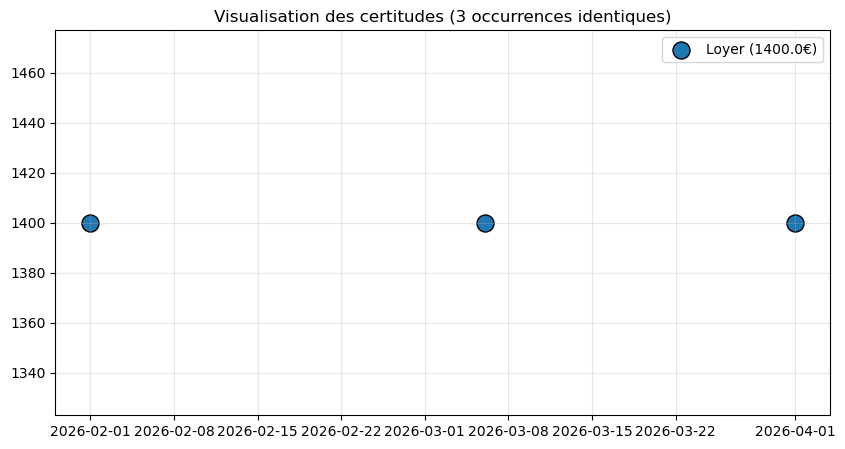

,Date,Intitule,Categorie,Valeur,Type
1,2026-04-01,Loyer,Essentiel,1400.0,Depense
13,2026-03-06,Loyer,Essentiel,1400.0,Depense
28,2026-02-01,Loyer,Essentiel,1400.0,Depense


In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Préparation avec NETTOYAGE STRICT
df_test = compta.liste_compte[0].df.copy()

# On nettoie les textes (Majuscules/Minuscules et espaces inutiles)
df_test['Intitule'] = df_test['Intitule'].astype(str).str.strip().str.capitalize()
df_test['Categorie'] = df_test['Categorie'].astype(str).str.strip().str.capitalize()

# On s'assure que les dates et valeurs sont propres
df_test['Date'] = pd.to_datetime(df_test['Date'], dayfirst=True, format='mixed')
df_test['Valeur'] = pd.to_numeric(df_test['Valeur'], errors='coerce')

# 2. Filtrer les 3 derniers mois
last_date = df_test['Date'].max()
three_months_ago = last_date - pd.DateOffset(months=3)
df_recent = df_test[df_test['Date'] >= three_months_ago]

# 3. Groupement (on ajoute Categorie et Valeur pour être sûr)
# On cherche les lignes où (Intitule + Categorie + Valeur) sont identiques
duplicates = df_recent.groupby(['Intitule', 'Categorie', 'Valeur']).filter(lambda x: len(x) >= 3)

# 4. Affichage
if duplicates.empty:
    print("❌ Toujours rien. Vérifie si 'Type' (Depense/Revenu) est identique sur les 3 lignes.")
else:
    print(f"✅ Trouvé ! {len(duplicates)} lignes correspondent à tes critères.")
    
    # Le Plot
    plt.figure(figsize=(10, 5))
    for name, group in duplicates.groupby('Intitule'):
        plt.scatter(group['Date'], group['Valeur'], label=f"{name} ({group['Valeur'].iloc[0]}€)", s=150, edgecolors='black')
    
    plt.title("Visualisation des certitudes (3 occurrences identiques)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    display(duplicates[['Date', 'Intitule', 'Categorie', 'Valeur', 'Type']])

In [38]:
import pandas as pd

# 1. Récupération et Nettoyage
df_p = compta.liste_compte[1].df.copy()
df_p['Date'] = pd.to_datetime(df_p['Date'], dayfirst=True, format='mixed')
df_p['Intitule'] = df_p['Intitule'].astype(str).str.strip().str.capitalize()
df_p['Valeur'] = pd.to_numeric(df_p['Valeur'], errors='coerce')

# 2. FILTRE TEMPOREL : Les 3 derniers mois à partir de la dernière date connue
derniere_date = df_p['Date'].max()
nb = 6
trois_mois_en_arriere = derniere_date - pd.DateOffset(months=nb)

# On ne garde que les transactions récentes
df_recent = df_p[df_p['Date'] >= trois_mois_en_arriere].copy()

# 3. Groupe par Intitule sur cette période restreinte
stats = df_recent.groupby(['Intitule', 'Categorie', 'Classe', 'Type']).agg({
    'Valeur': ['count', 'mean'],
    'Date': lambda x: x.dt.day.mode()[0]
}).reset_index()

# Renommage des colonnes
stats.columns = ['Intitule', 'Categorie', 'Classe', 'Type', 'Nombre', 'Valeur_Moyenne', 'Jour_Habituel']

# 4. TA LISTE DE CERTITUDES (au moins 3 fois sur les 3 derniers mois)
certitudes = stats[stats['Nombre'] >= nb//2]

print(f"--- ANALYSE DU {trois_mois_en_arriere.strftime('%d/%m/%Y')} AU {derniere_date.strftime('%d/%m/%Y')} ---")
if certitudes.empty:
    print("❌ Aucune certitude trouvée sur les 3 derniers mois.")
else:
    print(f"✅ {len(certitudes)} certitudes détectées :")
    display(certitudes)

--- ANALYSE DU 04/02/2026 AU 04/08/2026 ---
✅ 2 certitudes détectées :


,Intitule,Categorie,Classe,Type,Nombre,Valeur_Moyenne,Jour_Habituel
5,Bouffe,Essentiel,Nourriture,Depense,3,11.333333,10
8,Cotisation,Banque,Cotisation,Depense,3,3.500000,6


In [39]:
import pandas as pd
import unicodedata

def normalize_text(text):
    if pd.isna(text):
        return ""
    # 1. Mise en minuscules et retrait des espaces inutiles
    text = str(text).lower().strip()
    # 2. Suppression des accents (Normalisation Unicode)
    text = unicodedata.normalize('NFD', text)
    text = "".join([c for c in text if unicodedata.category(c) != 'Mn'])
    return text.capitalize()

# 1. Récupération et Nettoyage de base
df_p = compta.liste_compte[1].df.copy()
df_p['Date'] = pd.to_datetime(df_p['Date'], dayfirst=True, format='mixed')
df_p['Valeur'] = pd.to_numeric(df_p['Valeur'], errors='coerce')

# 2. Nettoyage RÉSILIENT (Accents + Majuscules)
df_p['Intitule'] = df_p['Intitule'].apply(normalize_text)
df_p['Categorie'] = df_p['Categorie'].apply(normalize_text)

# 3. FILTRE TEMPOREL (3 derniers mois)
derniere_date = df_p['Date'].max()
trois_mois_en_arriere = derniere_date - pd.DateOffset(months=nb)
df_recent = df_p[df_p['Date'] >= trois_mois_en_arriere].copy()

# 4. Groupe par Intitule (Moyenne des prix + Jour le plus fréquent)
stats = df_recent.groupby(['Intitule', 'Categorie', 'Classe', 'Type']).agg({
    'Valeur': ['count', 'mean'],
    'Date': lambda x: x.dt.day.mode()[0]
}).reset_index()

stats.columns = ['Intitule', 'Categorie', 'Classe', 'Type', 'Nombre', 'Valeur_Moyenne', 'Jour_Habituel']

# 5. TA LISTE DE CERTITUDES
certitudes = stats[stats['Nombre'] >= nb//2]

print(f"--- ANALYSE RÉSILIENTE DU {trois_mois_en_arriere.strftime('%d/%m/%Y')} AU {derniere_date.strftime('%d/%m/%Y')} ---")
if certitudes.empty:
    print("❌ Aucune certitude trouvée. Même avec le nettoyage, rien n'apparaît 3 fois.")
else:
    display(certitudes)

--- ANALYSE RÉSILIENTE DU 04/02/2026 AU 04/08/2026 ---


,Intitule,Categorie,Classe,Type,Nombre,Valeur_Moyenne,Jour_Habituel
5,Bouffe,Essentiel,Nourriture,Depense,3,11.333333,10
8,Cotisation,Banque,Cotisation,Depense,3,3.500000,6
